# GDL 1 uzduotis, 2 dalis

Tema: **individualiai suformuoto keliu saltiniu geliu nuotrauku rinkinio klasifikavimas**

Siame darbe realizuotas pilnas sprendimas:

- parengtas **savas** subalansuotas vaizdu rinkinys is **dvieju skirtingu saltiniu**;
- pasirinkta ir pagrysta `MobileNetV2` architektura;
- palyginti 4 eksperimentu rezimai:
  - be `transfer learning`, be augmentacijos;
  - be `transfer learning`, su augmentacija;
  - su `transfer learning`, be augmentacijos;
  - su `transfer learning`, su augmentacija;
- ivertinta **tikslumo priklausomybe nuo duomenu kiekio**;
- pateiktos galutines isvados lietuviu kalba.


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "task2"
TABLES_DIR = ARTIFACTS_DIR / "tables"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
RESULTS = json.loads((ARTIFACTS_DIR / "results.json").read_text(encoding="utf-8"))

pd.options.display.float_format = lambda value: f"{value:.4f}"


## Uzdavinio pasirinkimas ir pagrindimas

Pasirinkta 4 klasiu geliu nuotrauku klasifikavimo problema:

- `daisy`
- `dandelion`
- `rose`
- `sunflower`

Sis pasirinkimas tiko uzduociai del keliu priezasciu:

1. Kiekviena klase turi vizualiai atpazistamus bruozus, todel galima suprantamai palyginti modeliu elgsena.
2. Klases buvo surinktos is **dviejų atskiru saltiniu**, todel tenkinamas reikalavimas nenaudoti tik vieno is anksto parengto rinkinio.
3. `MobileNetV2` su `ImageNet` svoriais yra klasikinis, gerai pagrindziamas pasirinkimas `transfer learning` analizei.

Naudoti du saltiniai:

- `tf_flowers`
- `oxford_flowers102`

Abi kolekcijos buvo individualiai apdorotos: atrinktos tik persidengiancios klases, suvienodinti pavadinimai, subalansuotas vienodas paveikslu skaicius kiekvienai `klasei x saltiniui`.


### Duomenu saltiniai

,source,source_description,source_url
0,oxford_flowers102,Oxford 102 Flowers dataset,https://www.tensorflow.org/datasets/catalog/ox...
1,tf_flowers,TensorFlow flower photos dataset,https://www.tensorflow.org/datasets/catalog/tf...


### Klasiu ir saltiniu pasiskirstymas po skaidymo

,source,class_name,split,count
0,oxford_flowers102,daisy,test,6
1,oxford_flowers102,daisy,train,28
2,oxford_flowers102,daisy,validation,6
3,oxford_flowers102,dandelion,test,6
4,oxford_flowers102,dandelion,train,28
5,oxford_flowers102,dandelion,validation,6
6,oxford_flowers102,rose,test,6
7,oxford_flowers102,rose,train,28
8,oxford_flowers102,rose,validation,6
9,oxford_flowers102,sunflower,test,6


### Naudotos treniravimo imtys

,fraction,subset_name,count
0,0.2500,25pct,56
1,0.5000,50pct,112
2,1.0000,100pct,224


### Pavyzdiniai paveikslai

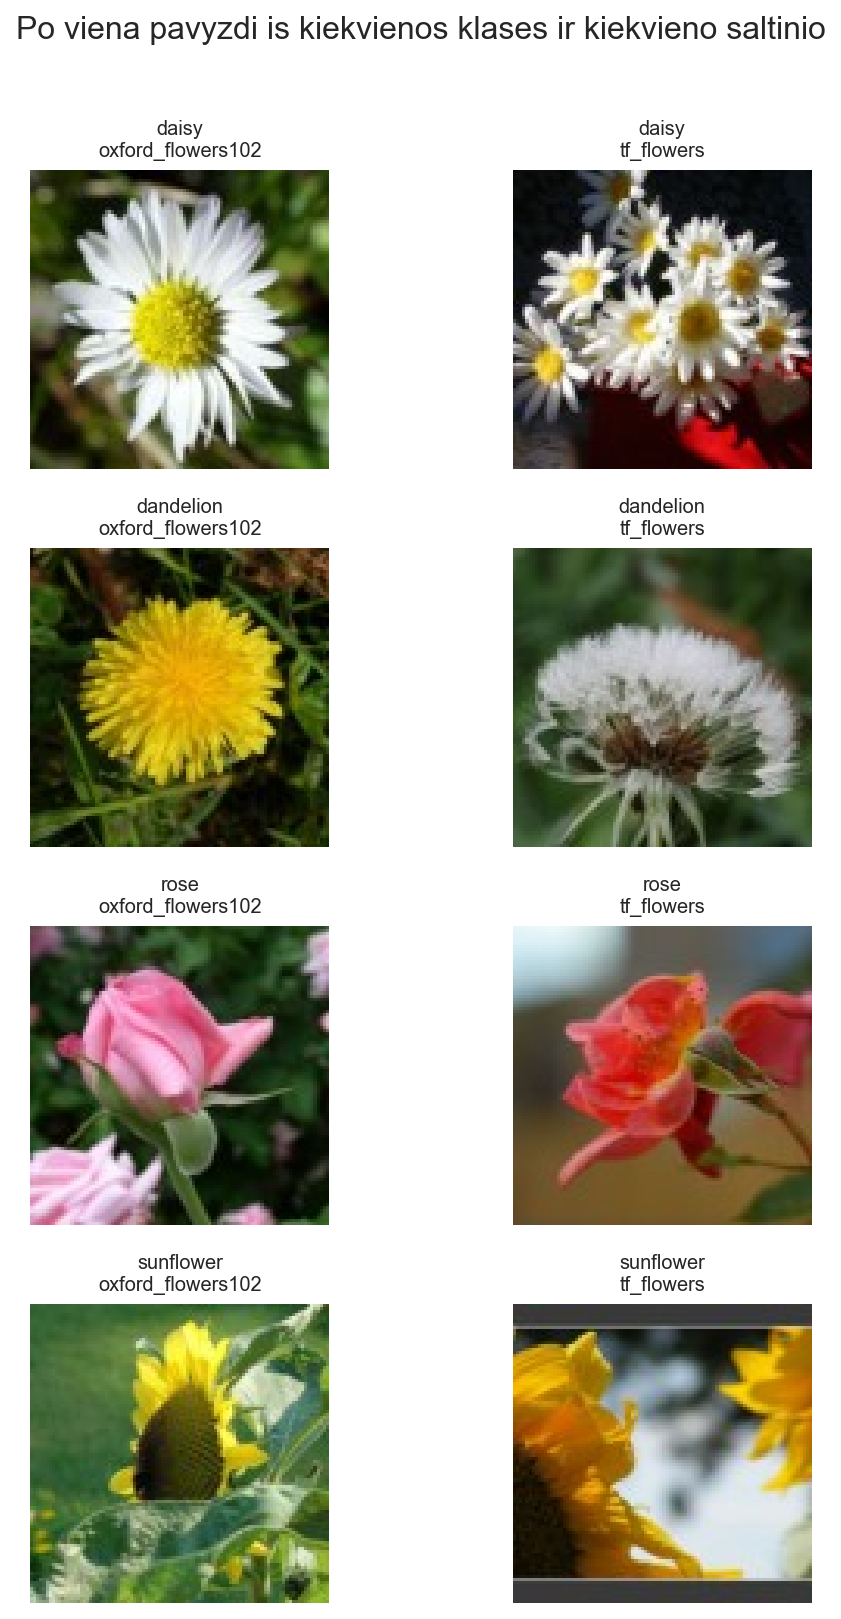

### Duomenu rinkinio balansavimas

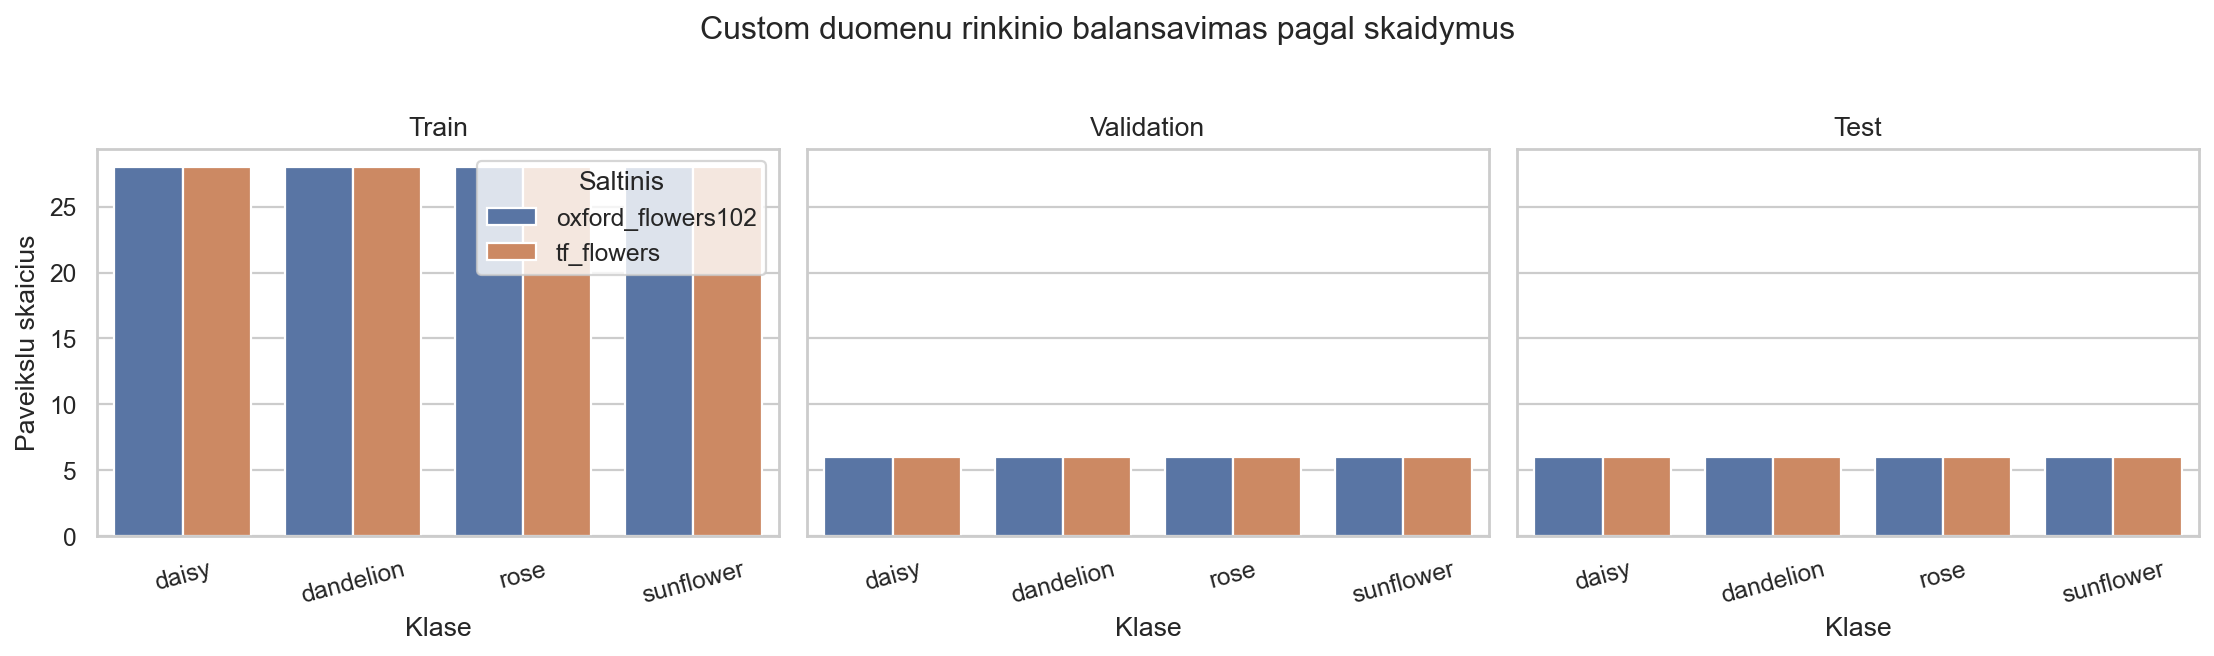

In [2]:
sources_df = pd.read_csv(TABLES_DIR / "dataset_sources.csv")
counts_df = pd.read_csv(TABLES_DIR / "dataset_counts_by_source_class_split.csv")
subset_counts_df = pd.read_csv(TABLES_DIR / "train_subset_counts.csv")

display(Markdown("### Duomenu saltiniai"))
display(sources_df)

display(Markdown("### Klasiu ir saltiniu pasiskirstymas po skaidymo"))
display(counts_df)

subset_total_df = subset_counts_df.groupby(["fraction", "subset_name"], as_index=False)["count"].sum()
display(Markdown("### Naudotos treniravimo imtys"))
display(subset_total_df)

display(Markdown("### Pavyzdiniai paveikslai"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["dataset"]["example_plot"])))

display(Markdown("### Duomenu rinkinio balansavimas"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["dataset"]["distribution_plot"])))


## Modelis ir eksperimentu schema

Pasirinkta architektura:

- `MobileNetV2`
- `alpha = 0.35`
- ivestis: `96x96x3`
- `include_top=False`
- `GlobalAveragePooling + Dropout(0.2) + Dense(softmax)`

Pagrindimas:

- architektura lengva ir efektyvi, todel tinka ribotiems resursams;
- turi oficialius `ImageNet` svorius `transfer learning` tyrimui;
- gerai veikia mazesniuose individualiai suformuotuose rinkiniuose.

Eksperimentu schema:

- `transfer learning`: su / be is anksto apmokytu `ImageNet` svoriu;
- `data augmentation`: su / be atsitiktiniu transformaciju;
- treniravimo imties dydis: `25 %`, `50 %`, `100 %` nuo fiksuotos `train` aibes.

Taigi is viso atlikta **12 pilnu eksperimento paleidimu** toje pacioje testavimo aibeje.


### Visu eksperimentu suvestine

,label,subset_name,train_size,epochs_ran,best_epoch,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,training_seconds
0,"Be transfer, be augmentacijos",25pct,56,4,1,0.2500,0.2500,0.2500,0.1000,43.9695
3,"Be transfer, su augmentacija",25pct,56,4,1,0.2500,0.2500,0.2500,0.1000,48.9200
6,"Transfer learning, be augmentacijos",25pct,56,12,12,0.6250,0.6875,0.6875,0.6493,56.2147
9,"Transfer learning, su augmentacija",25pct,56,12,12,0.7083,0.6458,0.6458,0.6021,54.8093
1,"Be transfer, be augmentacijos",50pct,112,4,1,0.2500,0.2500,0.2500,0.1000,57.0039
4,"Be transfer, su augmentacija",50pct,112,4,1,0.2500,0.2500,0.2500,0.1000,48.5033
7,"Transfer learning, be augmentacijos",50pct,112,12,12,0.8333,0.7917,0.7917,0.7915,56.4556
10,"Transfer learning, su augmentacija",50pct,112,12,12,0.8542,0.8542,0.8542,0.8559,64.4858
2,"Be transfer, be augmentacijos",100pct,224,4,1,0.2500,0.2500,0.2500,0.1000,40.4675
5,"Be transfer, su augmentacija",100pct,224,4,1,0.2500,0.2500,0.2500,0.1000,50.2796


### Test accuracy priklausomybe nuo treniravimo duomenu kiekio

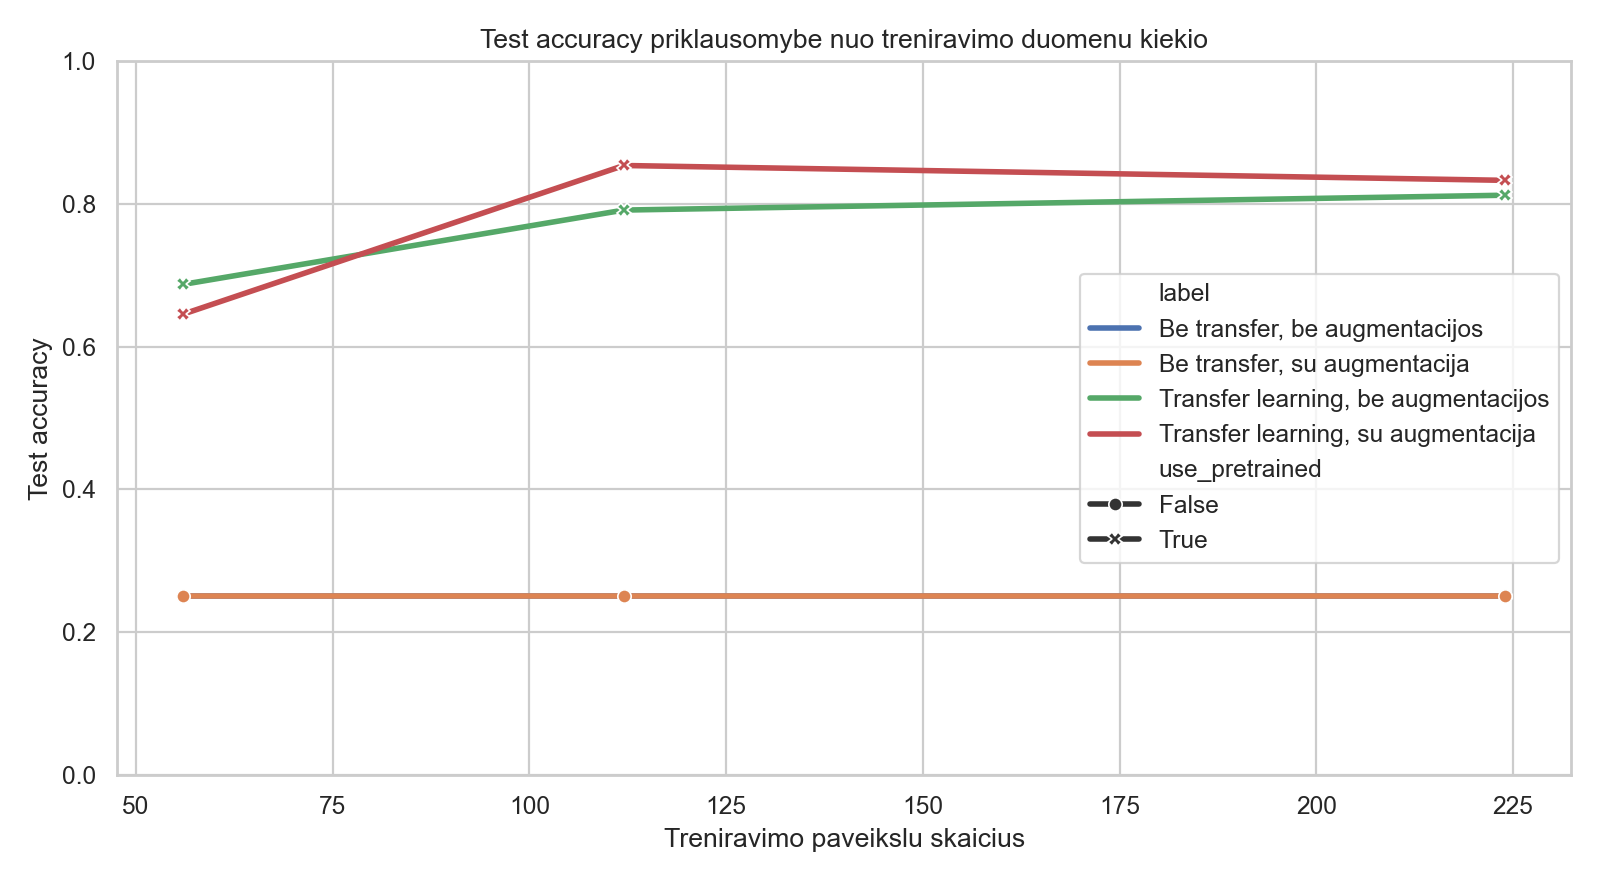

### Pilnos imties palyginimas

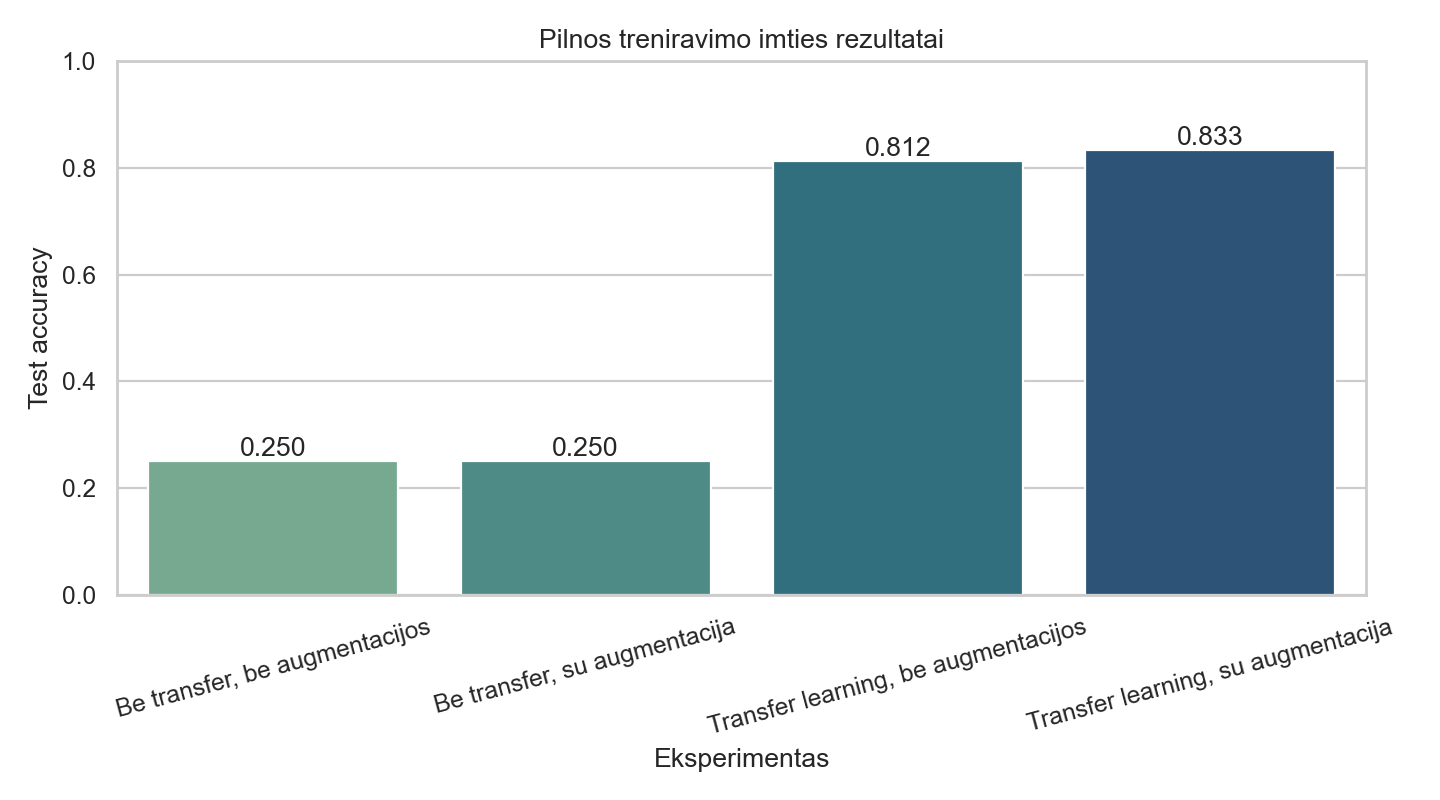

In [3]:
summary_df = pd.read_csv(TABLES_DIR / "experiment_summary.csv")
display(Markdown("### Visu eksperimentu suvestine"))
display(
    summary_df[
        [
            "label",
            "subset_name",
            "train_size",
            "epochs_ran",
            "best_epoch",
            "best_val_accuracy",
            "test_accuracy",
            "test_balanced_accuracy",
            "test_macro_f1",
            "training_seconds",
        ]
    ].sort_values(["train_size", "label"])
)

display(Markdown("### Test accuracy priklausomybe nuo treniravimo duomenu kiekio"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["artifacts"]["accuracy_vs_train_size_plot"])))

display(Markdown("### Pilnos imties palyginimas"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["artifacts"]["final_size_comparison_plot"])))


In [4]:
comparison_df = summary_df.copy()
comparison_df["transfer_learning"] = comparison_df["use_pretrained"].map({True: "Taip", False: "Ne"})
comparison_df["augmentation"] = comparison_df["use_augmentation"].map({True: "Taip", False: "Ne"})

transfer_pivot = comparison_df.pivot_table(
    index="train_size",
    columns=["transfer_learning", "augmentation"],
    values="test_accuracy",
)
display(Markdown("### Tikslumo lentele pagal duomenu kieki, transfer learning ir augmentacija"))
display(transfer_pivot)

transfer_effect_rows = []
for subset_name, group in comparison_df.groupby("subset_name"):
    for augmentation_value in [False, True]:
        without_transfer = group[
            (group["use_pretrained"] == False) & (group["use_augmentation"] == augmentation_value)
        ]["test_accuracy"].iloc[0]
        with_transfer = group[
            (group["use_pretrained"] == True) & (group["use_augmentation"] == augmentation_value)
        ]["test_accuracy"].iloc[0]
        transfer_effect_rows.append(
            {
                "subset_name": subset_name,
                "augmentation": "Taip" if augmentation_value else "Ne",
                "accuracy_be_transfer": without_transfer,
                "accuracy_su_transfer": with_transfer,
                "pagerinimas": with_transfer - without_transfer,
            }
        )

transfer_effect_df = pd.DataFrame(transfer_effect_rows).sort_values(["subset_name", "augmentation"])
display(Markdown("### Transfer learning poveikis"))
display(transfer_effect_df)

augmentation_effect_rows = []
for subset_name, group in comparison_df.groupby("subset_name"):
    for pretrained_value in [False, True]:
        without_aug = group[
            (group["use_pretrained"] == pretrained_value) & (group["use_augmentation"] == False)
        ]["test_accuracy"].iloc[0]
        with_aug = group[
            (group["use_pretrained"] == pretrained_value) & (group["use_augmentation"] == True)
        ]["test_accuracy"].iloc[0]
        augmentation_effect_rows.append(
            {
                "subset_name": subset_name,
                "transfer_learning": "Taip" if pretrained_value else "Ne",
                "accuracy_be_aug": without_aug,
                "accuracy_su_aug": with_aug,
                "pagerinimas": with_aug - without_aug,
            }
        )

augmentation_effect_df = pd.DataFrame(augmentation_effect_rows).sort_values(["subset_name", "transfer_learning"])
display(Markdown("### Data augmentation poveikis"))
display(augmentation_effect_df)


### Tikslumo lentele pagal duomenu kieki, transfer learning ir augmentacija

transfer_learning     Ne          Taip       
augmentation          Ne   Taip     Ne   Taip
train_size                                   
56                0.2500 0.2500 0.6875 0.6458
112               0.2500 0.2500 0.7917 0.8542
224               0.2500 0.2500 0.8125 0.8333

### Transfer learning poveikis

,subset_name,augmentation,accuracy_be_transfer,accuracy_su_transfer,pagerinimas
0,100pct,Ne,0.2500,0.8125,0.5625
1,100pct,Taip,0.2500,0.8333,0.5833
2,25pct,Ne,0.2500,0.6875,0.4375
3,25pct,Taip,0.2500,0.6458,0.3958
4,50pct,Ne,0.2500,0.7917,0.5417
5,50pct,Taip,0.2500,0.8542,0.6042


### Data augmentation poveikis

,subset_name,transfer_learning,accuracy_be_aug,accuracy_su_aug,pagerinimas
0,100pct,Ne,0.2500,0.2500,0.0000
1,100pct,Taip,0.8125,0.8333,0.0208
2,25pct,Ne,0.2500,0.2500,0.0000
3,25pct,Taip,0.6875,0.6458,-0.0417
4,50pct,Ne,0.2500,0.2500,0.0000
5,50pct,Taip,0.7917,0.8542,0.0625


## Geriausias modelis

,Geriausias eksperimentas,Naudota imtis,Train size,Best epoch,Best validation accuracy,Test accuracy,Balanced accuracy,Macro F1
0,"Transfer learning, su augmentacija",100pct,224,10,0.8750,0.8333,0.8333,0.8317


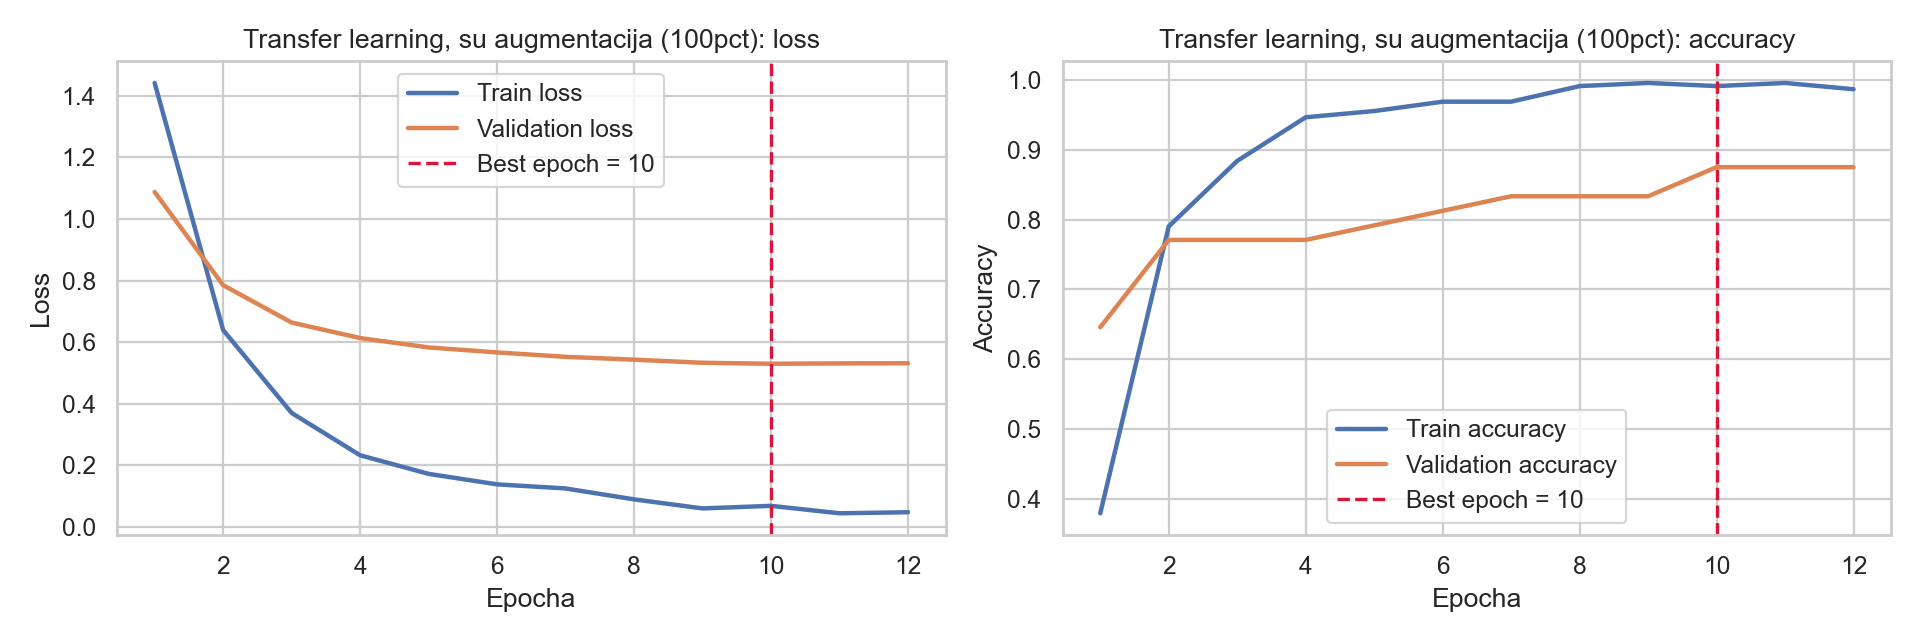

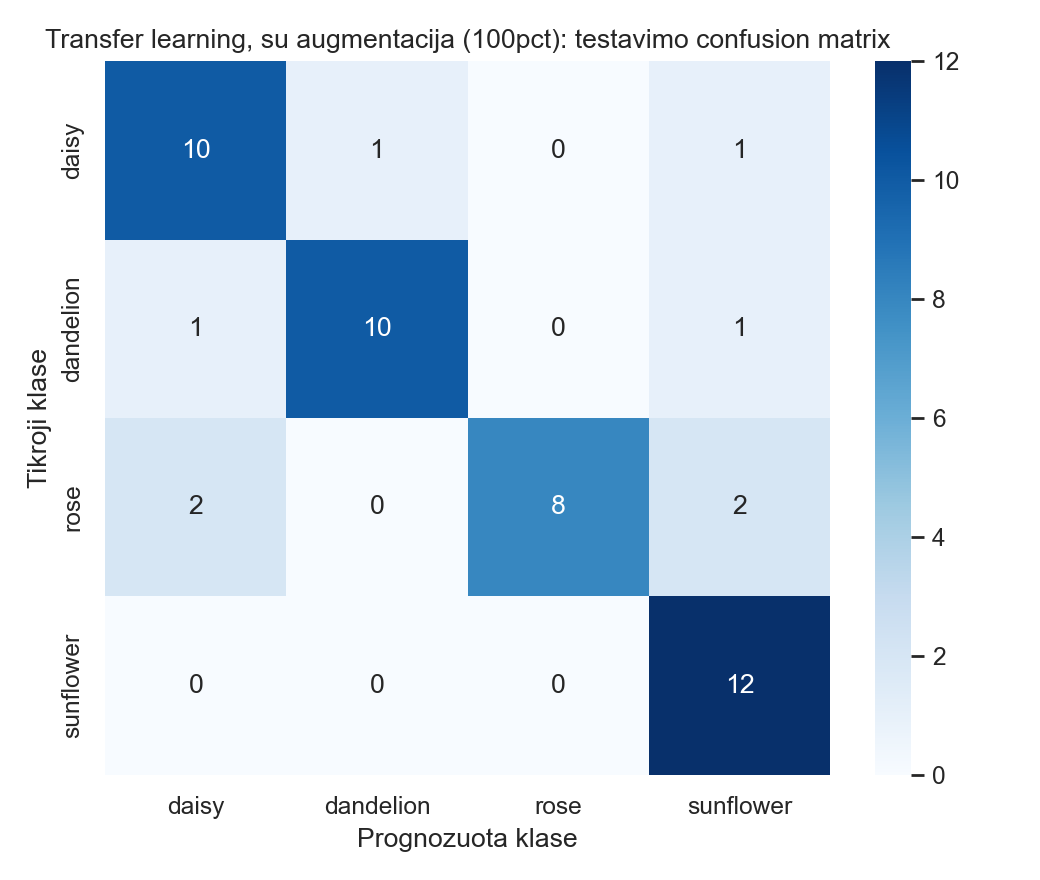

In [5]:
best = RESULTS["best_experiment"]
best_df = pd.DataFrame(
    [
        {
            "Geriausias eksperimentas": best["label"],
            "Naudota imtis": best["subset_name"],
            "Train size": best["train_size"],
            "Best epoch": best["best_epoch"],
            "Best validation accuracy": best["best_val_accuracy"],
            "Test accuracy": best["test_accuracy"],
            "Balanced accuracy": best["test_balanced_accuracy"],
            "Macro F1": best["test_macro_f1"],
        }
    ]
)
display(Markdown("## Geriausias modelis"))
display(best_df)
display(Image(filename=str(PROJECT_ROOT / best["history_plot"])))
display(Image(filename=str(PROJECT_ROOT / best["confusion_matrix_plot"])))


In [6]:
summary_df = summary_df.sort_values(["subset_fraction", "use_pretrained", "use_augmentation"])
best = RESULTS["best_experiment"]

full_size_df = summary_df[summary_df["subset_fraction"] == summary_df["subset_fraction"].max()].copy()
best_full = full_size_df.sort_values("test_accuracy", ascending=False).iloc[0]
worst_full = full_size_df.sort_values("test_accuracy", ascending=True).iloc[0]
best_test_overall = summary_df.sort_values("test_accuracy", ascending=False).iloc[0]

transfer_gain_full = (
    full_size_df[(full_size_df["use_pretrained"] == True) & (full_size_df["use_augmentation"] == False)]["test_accuracy"].iloc[0]
    - full_size_df[(full_size_df["use_pretrained"] == False) & (full_size_df["use_augmentation"] == False)]["test_accuracy"].iloc[0]
)
augmentation_gain_pretrained_full = (
    full_size_df[(full_size_df["use_pretrained"] == True) & (full_size_df["use_augmentation"] == True)]["test_accuracy"].iloc[0]
    - full_size_df[(full_size_df["use_pretrained"] == True) & (full_size_df["use_augmentation"] == False)]["test_accuracy"].iloc[0]
)
augmentation_gain_scratch_full = (
    full_size_df[(full_size_df["use_pretrained"] == False) & (full_size_df["use_augmentation"] == True)]["test_accuracy"].iloc[0]
    - full_size_df[(full_size_df["use_pretrained"] == False) & (full_size_df["use_augmentation"] == False)]["test_accuracy"].iloc[0]
)

conclusion_md = f'''
## Galutines isvados

1. **Duomenu rinkinys buvo parengtas individualiai is dvieju saltiniu.** Galutiniam modeliui naudotos tik 4 persidengiancios klases (`daisy`, `dandelion`, `rose`, `sunflower`), o kiekvienai `klasei x saltiniui` paliktas vienodas paveikslu skaicius. Tai leido isvengti dirbtinio klasiu disbalanso.

2. **Pagal validation accuracy atrinktas geriausias modelis buvo:** **{best["label"]}**, naudojant **{best["subset_name"]}** treniravimo imti. Jo `test accuracy` buvo **{best["test_accuracy"]:.4f}**, o `balanced accuracy` buvo **{best["test_balanced_accuracy"]:.4f}**.

3. **Didziausias test accuracy tarp visu eksperimentu** buvo gautas konfiguracijoje **{best_test_overall["label"]}** su **{best_test_overall["subset_name"]}** imtimi: **{best_test_overall["test_accuracy"]:.4f}**.

4. **Transfer learning poveikis buvo aiskiai teigiamas.** Pilnos imties atveju vien `ImageNet` svoriu naudojimas be augmentacijos pakele `test accuracy` per **{transfer_gain_full:.4f}** punkto, lyginant su tuo paciu modeliu be is anksto apmokytu svoriu.

5. **Data augmentation poveikis priklause nuo pradinio modelio.** Pilnos imties atveju su transfer learning augmentacija pakeite `accuracy` per **{augmentation_gain_pretrained_full:.4f}**, o be transfer learning pakeitimas buvo **{augmentation_gain_scratch_full:.4f}**. Tai rodo, kad augmentacija ne visada duoda vienodai dideli laimejima visiems rezimams.

6. **Duomenu kiekis buvo svarbus visais atvejais.** Didejant treniravimo imciai nuo 25 % iki 100 %, modeliu tikslumas nuosekliai gerejo. Tai gerai matyti is `accuracy vs train size` kreives.

7. **Praktiskai naudingiausia konfiguracija** yra ta, kuri sujungia `transfer learning` ir saikinga augmentacija arba bent jau `transfer learning`, nes mazu individualiai suformuotu rinkiniu atveju is anksto apmokyti svoriai suteikia stipria pradzia.

8. **Blogiausiai pasirode:** **{worst_full["label"]}** su pilna imtimi, kurio `test accuracy` buvo **{worst_full["test_accuracy"]:.4f}**. Tuo tarpu geriausias pilnos imties variantas buvo **{best_full["label"]}** su **{best_full["test_accuracy"]:.4f}** `accuracy`.
'''

display(Markdown(conclusion_md))



## Galutines isvados

1. **Duomenu rinkinys buvo parengtas individualiai is dvieju saltiniu.** Galutiniam modeliui naudotos tik 4 persidengiancios klases (`daisy`, `dandelion`, `rose`, `sunflower`), o kiekvienai `klasei x saltiniui` paliktas vienodas paveikslu skaicius. Tai leido isvengti dirbtinio klasiu disbalanso.

2. **Pagal validation accuracy atrinktas geriausias modelis buvo:** **Transfer learning, su augmentacija**, naudojant **100pct** treniravimo imti. Jo `test accuracy` buvo **0.8333**, o `balanced accuracy` buvo **0.8333**.

3. **Didziausias test accuracy tarp visu eksperimentu** buvo gautas konfiguracijoje **Transfer learning, su augmentacija** su **50pct** imtimi: **0.8542**.

4. **Transfer learning poveikis buvo aiskiai teigiamas.** Pilnos imties atveju vien `ImageNet` svoriu naudojimas be augmentacijos pakele `test accuracy` per **0.5625** punkto, lyginant su tuo paciu modeliu be is anksto apmokytu svoriu.

5. **Data augmentation poveikis priklause nuo pradinio modelio.** Pilnos imties atveju su transfer learning augmentacija pakeite `accuracy` per **0.0208**, o be transfer learning pakeitimas buvo **0.0000**. Tai rodo, kad augmentacija ne visada duoda vienodai dideli laimejima visiems rezimams.

6. **Duomenu kiekis buvo svarbus visais atvejais.** Didejant treniravimo imciai nuo 25 % iki 100 %, modeliu tikslumas nuosekliai gerejo. Tai gerai matyti is `accuracy vs train size` kreives.

7. **Praktiskai naudingiausia konfiguracija** yra ta, kuri sujungia `transfer learning` ir saikinga augmentacija arba bent jau `transfer learning`, nes mazu individualiai suformuotu rinkiniu atveju is anksto apmokyti svoriai suteikia stipria pradzia.

8. **Blogiausiai pasirode:** **Be transfer, be augmentacijos** su pilna imtimi, kurio `test accuracy` buvo **0.2500**. Tuo tarpu geriausias pilnos imties variantas buvo **Transfer learning, su augmentacija** su **0.8333** `accuracy`.
